### Yang-Sun's sciript of LFP Extraction and Ripple detection

In [1]:
import datajoint as dj
import numpy as np
import spyglass
import jax
import os

#before, make sure you are not conflicting with others
#run nvidia-smi on your ssh and determine which GPU you are going to occupy (spyglass can only use one GPU at a time)
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.99"
device_id = 6 # or whatever number GPU you want
device = jax.devices()[device_id]
jax.config.update("jax_default_device", device)


# change to the upper level folder to detect dj_local_conf.json
if os.path.basename(os.getcwd()) == "decoding":
    os.chdir("..")
dj.config["enable_python_native_blobs"] = True
dj.config.load("dj_local_conf.json")  # load config for database connection info

print("Default device setting:", jax.default_backend())
print("Explicit device you picked:", device)
print(spyglass.__file__) # confirm your environment is set up correctly
print(spyglass.__version__) # confirm your spyglass version

[2026-03-17 22:27:59,794][INFO]: DataJoint 0.14.6 connected to yshwang@lmf-db.cin.ucsf.edu:3306
2026-03-17 22:28:03.601022: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_helpers.cc:63] Unable to enable peer access between GPUs 0 and 9; status: INTERNAL: failed to enable peer access from 0x7fe8b08f81c0 to 0x7fe8a08f8820: CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
2026-03-17 22:28:03.617090: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_helpers.cc:63] Unable to enable peer access between GPUs 1 and 9; status: INTERNAL: failed to enable peer access from 0x7fe8908f8620 to 0x7fe8a08f8820: CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
2026-03-17 22:28:03.630822: W external/org_tensorflow/tensorflow/compiler/xla/pjrt/gpu/gpu_helpers.cc:63] Unable to enable peer access between GPUs 2 and 9; status: INTERNAL: failed to enable peer access from 0x7fe8b88b5180 to 0x7fe8a08f8820: CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhau

Default device setting: gpu
Explicit device you picked: gpu:6
/home/yshwang/code/spyglass/src/spyglass/__init__.py
0.5.5a2.dev43+g50be44655.d20260217


## Select your data and make sure ***your data excists***

In [4]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.utils.nwb_helper_fn import get_nwb_file
import spyglass.spikesorting.v1 as sgs
from spyglass.common import Nwbfile

nwb_file_name = "IM-1478_20220726.nwb"
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
nwb_file_abspath = Nwbfile.get_abs_path(nwb_copy_file_name)
nwbf = get_nwb_file(nwb_file_abspath)
print(f"File created on {nwbf.file_create_date[0].strftime('%m/%d/%Y %H:%M:%S')}")
print(f"Source script version {nwbf.source_script}")



# Other parameters
lfp_electrode_group_name = "hippocampus" # name of the shanks
interval_list_name = "00_r1"



File created on 01/26/2026 11:18:53
Source script version jdb_to_nwb 2.1.3.dev0+g029276d9a.d20251210


## Create Filters (1st filter downsampling with 400 Hz high-cut)
Next, we create the standard LFP Filters. This only needs to be done once. If not, you gotta create one

In [3]:
# TODO : understand why this is 29993, not 29992 (29991.591927034668)
import spyglass.common as sgc
from spyglass.common.common_ephys import Raw

# Check how what data_fs will be applied in the filter

nwbf_key = {"nwb_file_name": nwb_copy_file_name}
rawdata = (Raw & nwbf_key).fetch_nwb()[0]["raw"]

sampling_rate, raw_interval_list_name = (Raw & nwbf_key).fetch1(
    "sampling_rate", "interval_list_name"
)
print(sampling_rate, raw_interval_list_name)

sgc.FirFilterParameters().create_standard_filters()

# check if you have standard filter for your data. if not, you need to create one using the function below.
if len((sgc.FirFilterParameters() & {"filter_sampling_rate": sampling_rate}).fetch()) == 0:
    print("Your filter does not exist! Creating one for you...")
    standard_filter = sgc.FirFilterParameters() & {
        "filter_name": "LFP 0-400 Hz",
        "filter_sampling_rate": 30_000,
    }
    display(standard_filter)

    band_edges = standard_filter.fetch1("filter_band_edges")
    print(band_edges)

    sgc.FirFilterParameters().add_filter(
        filter_name="LFP 0-400 Hz",
        fs=sampling_rate,
        filter_type="lowpass",
        band_edges=band_edges,
        comments=f"standard LFP filter adapted for {sampling_rate} Hz data",
    )

    display(sgc.FirFilterParameters() & {"filter_name": "LFP 0-400 Hz"})
else:
    print("Your filter already exists!")
    display(sgc.FirFilterParameters() & {"filter_sampling_rate": sampling_rate})
    

29998.0 raw data valid times


Your filter already exists!


filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,filter_type,filter_low_stop lowest frequency for stop band for low frequency side of filter,filter_low_pass lowest frequency for pass band of low frequency side of filter,filter_high_pass highest frequency for pass band for high frequency side of filter,filter_high_stop highest frequency for stop band of high frequency side of filter,filter_comments comments about the filter,filter_band_edges numpy array containing the filter bands (redundant with individual parameters),filter_coeff numpy array containing the filter coefficients
IM-1478 LFP 0-400 Hz,29998,lowpass,0.0,0.0,400.0,425.0,standard LFP filter adapted for 29998 Hz,=BLOB=,=BLOB=


## Make LFP
Here, we will begin by creating a lfp group of just electrodes in the hippocampus region, and populate the lfp on a subsetted interval:

In [8]:
import pandas as pd
import spyglass.lfp as sglfp
import spyglass.position.v1 as sgp
import spyglass.lfp.analysis.v1 as lfp_analysis
from spyglass.lfp import LFPOutput
from spyglass.position import PositionOutput
import spyglass.ripple.v1 as sgrip
import spyglass.ripple.v1 as sgr

# ignore datajoint+jupyter async warnings
import warnings

warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)

# select hippocampus electrodes
electrodes_df = (
    pd.DataFrame(
        (
            sgc.Electrode
            & {"nwb_file_name": nwb_copy_file_name, "bad_channel": "False"}
        )
        * (sgc.BrainRegion & {"region_name": "Hippocampus CA1"})
    )
    .loc[
        :,
        [
            "nwb_file_name",
            "electrode_id",
            "region_name",
            "electrode_group_name",
        ],
    ]
    .sort_values(by="electrode_id")
)

# we will only use one electrode per electrode group
electrodes_df = pd.DataFrame(
    [
        electrodes_df[electrodes_df.electrode_group_name == str(i)].iloc[0]
        for i in np.unique(electrodes_df.electrode_group_name.values)
    ]
)

# create lfp_electrode_group
lfp_eg_key = {
    "nwb_file_name": nwb_copy_file_name,
    "lfp_electrode_group_name": lfp_electrode_group_name,
}

sglfp.lfp_electrode.LFPElectrodeGroup.create_lfp_electrode_group(
    nwb_file_name=nwb_copy_file_name,
    group_name=lfp_electrode_group_name,
    electrode_list=electrodes_df.electrode_id.tolist(),
    skip_duplicates=True,
)

# make the lfp selection
lfp_s_key = lfp_eg_key.copy()
lfp_s_key.update(
    {
        "target_interval_list_name": interval_list_name,
        "filter_name": (sgc.FirFilterParameters() & {"filter_sampling_rate": sampling_rate}).fetch1('filter_name'),
        "filter_sampling_rate": sampling_rate,  # sampling rate of the data (Hz)
        "target_sampling_rate": 1_000,  # smpling rate of the lfp output (Hz)
    }
)
print(lfp_s_key)
sglfp.v1.LFPSelection.insert1(lfp_s_key, skip_duplicates=True)

# populate the lfp. It takes about 10-15 mins for 120 mins data with 30kHz sampling rate
sglfp.v1.LFPV1.populate(lfp_s_key, display_progress=True)
sglfp.v1.LFPV1 & lfp_s_key

[22:32:39][INFO] Spyglass: Successfully created/updated LFPElectrodeGroup IM-1478_20220726_.nwb, hippocampus with 25 electrodes.
INFO:spyglass:Successfully created/updated LFPElectrodeGroup IM-1478_20220726_.nwb, hippocampus with 25 electrodes.


{'nwb_file_name': 'IM-1478_20220726_.nwb', 'lfp_electrode_group_name': 'hippocampus', 'target_interval_list_name': '00_r1', 'filter_name': 'IM-1478 LFP 0-400 Hz', 'filter_sampling_rate': 29998.0, 'target_sampling_rate': 1000}


LFPV1:   0%|          | 0/1 [00:00<?, ?it/s][22:32:50][INFO] Spyglass: Writing new NWB file IM-1478_20220726_N1QS5GXNVM.nwb
INFO:spyglass:Writing new NWB file IM-1478_20220726_N1QS5GXNVM.nwb
[22:32:56][INFO] Spyglass: LFP: found 1 intervals > 1.0 sec long.
INFO:spyglass:LFP: found 1 intervals > 1.0 sec long.
[22:33:41][INFO] Spyglass: Filtering data
INFO:spyglass:Filtering data
[22:33:41][INFO] Spyglass: Interval 0: loading data into memory
INFO:spyglass:Interval 0: loading data into memory
LFPV1: 100%|██████████| 1/1 [19:54<00:00, 1194.51s/it]


nwb_file_name name of the NWB file,lfp_electrode_group_name the name of this group of electrodes,target_interval_list_name descriptive name of this interval list,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,analysis_file_name name of the file,interval_list_name descriptive name of this interval list,lfp_object_id the NWB object ID for loading this object from the file,"lfp_sampling_rate the sampling rate, in HZ"
IM-1478_20220726_.nwb,hippocampus,00_r1,IM-1478 LFP 0-400 Hz,29998,IM-1478_20220726_N1QS5GXNVM.nwb,lfp_hippocampus_00_r1_valid times,83f96bdc-04c0-47e2-9d5d-9f1ca9b0f1ab,1034.0


## Populate Ripple Band (2nd filter with ripple 150-250 Hz)
We now create a filter for this frequency band

In [9]:
(LFPOutput.LFPV1() & lfp_s_key)
lfp_merge_id = (LFPOutput.LFPV1() & lfp_s_key).fetch1("merge_id")
lfp_key = {"merge_id": lfp_merge_id}
lfp_sampling_rate = LFPOutput.merge_get_parent(lfp_key).fetch1("lfp_sampling_rate")
print(lfp_sampling_rate)
sgc.FirFilterParameters() & "filter_name='Ripple 150-250 Hz'"

from spyglass.lfp.analysis.v1 import lfp_band

filter_name = "Ripple 150-250 Hz"
lfp_band_electrode_ids = (
    electrodes_df.electrode_id.tolist()
)  # assumes we've filtered these electrodes
lfp_band_sampling_rate = 1000  # desired sampling rate

# check if the filter for ripple band already exists. If not, create one.
if len((sgc.FirFilterParameters() & {"filter_sampling_rate": lfp_sampling_rate, "filter_name": "Ripple 150-250 Hz"}).fetch()) == 0:
    print("Your filter does not exist! Creating one for you...")
    sgc.FirFilterParameters().add_filter(
        filter_name="Ripple 150-250 Hz",
        fs=lfp_sampling_rate,
        filter_type="bandpass",
        band_edges=[140, 150, 250, 260],
        comments=f"ripple band filter for {lfp_sampling_rate} Hz data",
    )
    display(sgc.FirFilterParameters() & {"filter_name": "Ripple 150-250 Hz"})
else:
    print("Your filter already exists!")
    display(sgc.FirFilterParameters() & {"filter_sampling_rate": lfp_sampling_rate, "filter_name": "Ripple 150-250 Hz"})

# set the lfp band electrodes. This will create entries in LFPBandSelection, which is required for populating LFPBandV1
lfp_merge_id = (LFPOutput.LFPV1() & lfp_s_key).fetch1("merge_id")
lfp_band.LFPBandSelection().set_lfp_band_electrodes(
    nwb_file_name=nwb_copy_file_name,
    lfp_merge_id=lfp_merge_id,
    electrode_list=lfp_band_electrode_ids,
    filter_name=filter_name,
    interval_list_name=interval_list_name,
    reference_electrode_list=[-1],  # -1 means no ref electrode for all channels
    lfp_band_sampling_rate=lfp_band_sampling_rate,
)

lfp_band.LFPBandV1.populate(
    {"lfp_merge_id": lfp_merge_id, "filter_name": filter_name},
    display_progress=True,
)
lfp_band.LFPBandV1 & {"lfp_merge_id": lfp_merge_id, "filter_name": filter_name}

1034.0
Your filter already exists!


filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,filter_type,filter_low_stop lowest frequency for stop band for low frequency side of filter,filter_low_pass lowest frequency for pass band of low frequency side of filter,filter_high_pass highest frequency for pass band for high frequency side of filter,filter_high_stop highest frequency for stop band of high frequency side of filter,filter_comments comments about the filter,filter_band_edges numpy array containing the filter bands (redundant with individual parameters),filter_coeff numpy array containing the filter coefficients
Ripple 150-250 Hz,1034,bandpass,140.0,150.0,250.0,260.0,ripple band filter for 1034.0 Hz data,=BLOB=,=BLOB=


[23:10:30][INFO] Spyglass: It is recommended to use the same sampling rate as the original lfp data to avoid aliasing.
INFO:spyglass:It is recommended to use the same sampling rate as the original lfp data to avoid aliasing.
LFPBandV1:   0%|          | 0/1 [00:00<?, ?it/s][23:10:40][INFO] Spyglass: Writing new NWB file IM-1478_20220726_PLX00N4GZ9.nwb
INFO:spyglass:Writing new NWB file IM-1478_20220726_PLX00N4GZ9.nwb
[23:10:58][WARNING] Spyglass: Interval time warning: stop time larger than last timestamp, substituting last: 4373.824166666666 < 4373.8232
LFPBandV1: 100%|██████████| 1/1 [00:43<00:00, 43.76s/it]


lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,interval_list_name descriptive name of this interval list,lfp_band_object_id the NWB object ID for loading this object from the file
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,IM-1478_20220726_PLX00N4GZ9.nwb,00_r1 lfp band 1034Hz,2fb198a1-4eeb-4a4c-a72d-4ec6f5ebfa9d


## Selecting Ripple Analysis Electrodes
Next, we'll pick the electrodes on which we'll run ripple detection on, using
`RippleLFPSelection.set_lfp_electrodes`


We'll need the `nwb_file_name`, an `electrode_list`, and to a `group_name`.

- By default, `group_name` is set to CA1 for ripple detection, but we could
  alternatively use PFC.
- We use `nwb_file_name` to explore which electrodes are available for the
  `electrode_list`.


Now we can look at `electrode_id` in the `Electrode` table:



In [10]:
electrodes = (
    (sgc.Electrode() & {"nwb_file_name": nwb_copy_file_name})
    * (
        lfp_analysis.LFPBandSelection.LFPBandElectrode()
        & {
            "nwb_file_name": nwb_copy_file_name,
            "filter_name": filter_name,
            "target_interval_list_name": interval_list_name,
        }
    )
    * sgc.BrainRegion
).fetch(format="frame")
electrodes

probe_id  \
nwb_file_name         electrode_group_name electrode_id lfp_merge_id                         filter_name       filter_sampling_rate target_interval_list_name lfp_band_sampling_rate lfp_electrode_group_name reference_elect_id region_id                                                 
IM-1478_20220726_.nwb 10                   80           834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      11                   88           834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      12                   98           834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      13                   104          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      14                   112          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      15                   120          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      16                   130          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      17                   136          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      18                   145          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      19                   152          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      20                   160          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      21                   168          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
                      22                   177          834b5b3d-e184-4bd1-bef5-895fad426161 Ripple 150-250 Hz 1034                 00_r1                     1034                   hippocampus              -1                 64         256-ch Silicon Probe, 3mm length, 66um pitch   
            

For ripple detection, we want only the first good electrode on each shank. I will do this using pandas syntax but you could use datajoint to filter this table as well.

We only want the electrode_id to put in the `electrode_list`:


In [11]:
hpc_names = ["ca1", "hippocampus", "CA1", "Hippocampus", "Hippocampus CA1"]
electrode_list = np.unique(
    (
        electrodes.loc[
            (electrodes.region_name.isin(hpc_names))
        ]
        .reset_index()
        .electrode_id
    ).tolist()
)

electrode_list.sort()
electrode_list

array([ 57,  65,  72,  80,  88,  98, 104, 112, 120, 130, 136, 145, 152,
       160, 168, 177, 184, 192, 200, 208, 216, 225, 234, 240, 249])

By default, `set_lfp_electrodes` will use all the available electrodes from `LFPBandV1`.

We can insert into `RippleLFPSelection` and the `RippleLFPElectrode` part table,
passing the key for the entry from `LFPBandV1`, our `electrode_list`, and the
`group_name` into `set_lfp_electrodes`

In [12]:
group_name = "hippocampus"

lfp_band_key = (
    lfp_analysis.LFPBandV1()
    & {
        "filter_name": filter_name,
        "nwb_file_name": nwb_copy_file_name,
        "lfp_band_sampling_rate": lfp_sampling_rate,
    }
).fetch1("KEY")

sgr.RippleLFPSelection.set_lfp_electrodes(
    lfp_band_key,
    electrode_list=electrode_list,
    group_name=group_name,
)

sgr.RippleLFPSelection.RippleLFPElectrode() & {"group_name": group_name, "nwb_file_name": nwb_copy_file_name}

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,group_name,lfp_electrode_group_name the name of this group of electrodes,electrode_group_name electrode group name from NWBFile,electrode_id the unique number for this electrode,reference_elect_id the reference electrode to use; -1 for no reference
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,10,80,-1
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,11,88,-1
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,12,98,-1
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,13,104,-1
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,14,112,-1
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,15,120,-1
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,16,130,-1
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,17,136,-1
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,18,145,-1
834b5b3d-e184-4bd1-bef5-895fad426161,Ripple 150-250 Hz,1034,IM-1478_20220726_.nwb,00_r1,1034,hippocampus,hippocampus,19,152,-1


## Setting Ripple Parameters

- `filter_name`: which bandpass filter is used
- `speed_name`: the name of the speed parameters in `IntervalPositionInfo`

For the `Kay_ripple_detector` (options are currently Kay and Karlsson, see `ripple_detection` package for specifics) the parameters are:

- `speed_threshold` (cm/s): maximum speed the animal can move
- `minimum_duration` (s): minimum time above threshold
- `zscore_threshold` (std): minimum value to be considered a ripple, in standard
  deviations from mean
- `smoothing_sigma` (s): how much to smooth the signal in time
- `close_ripple_threshold` (s): exclude ripples closer than this amount


In [22]:
for i in sgrip.RippleParameters().fetch("ripple_param_name"):
    display((sgrip.RippleParameters() & {"ripple_param_name": i}).fetch1())

{'ripple_param_name': 'default',
 'ripple_param_dict': {'speed_name': 'head_speed',
  'ripple_detection_algorithm': 'Kay_ripple_detector',
  'ripple_detection_params': {'speed_threshold': 4.0,
   'minimum_duration': 0.015,
   'zscore_threshold': 2.0,
   'smoothing_sigma': 0.004,
   'close_ripple_threshold': 0.0}}}

{'ripple_param_name': 'default_denisse',
 'ripple_param_dict': {'speed_name': 'speed',
  'ripple_detection_algorithm': 'Kay_ripple_detector',
  'ripple_detection_params': {'speed_threshold': 4.0,
   'minimum_duration': 0.015,
   'zscore_threshold': 3.0,
   'smoothing_sigma': 0.004,
   'close_ripple_threshold': 0.0}}}

{'ripple_param_name': 'default_ms',
 'ripple_param_dict': {'speed_name': 'speed',
  'ripple_detection_algorithm': 'Kay_ripple_detector',
  'ripple_detection_params': {'speed_threshold': 4.0,
   'minimum_duration': 0.015,
   'zscore_threshold': 2.0,
   'smoothing_sigma': 0.004,
   'close_ripple_threshold': 0.0}}}

{'ripple_param_name': 'default_sharon',
 'ripple_param_dict': {'speed_name': 'speed',
  'ripple_detection_algorithm': 'Kay_ripple_detector',
  'ripple_detection_params': {'speed_threshold': 4.0,
   'minimum_duration': 0.015,
   'zscore_threshold': 2.0,
   'smoothing_sigma': 0.004,
   'close_ripple_threshold': 0.0}}}

{'ripple_param_name': 'default_trodes',
 'ripple_param_dict': {'speed_name': 'speed',
  'ripple_detection_algorithm': 'Kay_ripple_detector',
  'ripple_detection_params': {'speed_threshold': 4.0,
   'minimum_duration': 0.015,
   'zscore_threshold': 2.0,
   'smoothing_sigma': 0.004,
   'close_ripple_threshold': 0.0}}}

{'ripple_param_name': 'high_threshold_trodes_david',
 'ripple_param_dict': {'speed_name': 'speed',
  'ripple_detection_algorithm': 'Kay_ripple_detector',
  'ripple_detection_params': {'speed_threshold': 4.0,
   'minimum_duration': 0.015,
   'zscore_threshold': 5.0,
   'smoothing_sigma': 0.004,
   'close_ripple_threshold': 0.0}}}

{'ripple_param_name': 'medium_threshold_trodes_david',
 'ripple_param_dict': {'speed_name': 'speed',
  'ripple_detection_algorithm': 'Kay_ripple_detector',
  'ripple_detection_params': {'speed_threshold': 4.0,
   'minimum_duration': 0.015,
   'zscore_threshold': 3.5,
   'smoothing_sigma': 0.004,
   'close_ripple_threshold': 0.0}}}

In [23]:
ripple_param_name = "default_trodes"

if False:
    new_ripple_param_name = "PUT_YOUR_NEW_NAME_HERE"
    sgr.RippleParameters().insert_default()
    sgr.RippleParameters.insert1(
        {
            "ripple_param_name": "default_trodes",
            "ripple_param_dict": {
                "speed_name": "speed",  # name of the speed field in the position data
                "ripple_detection_algorithm": "Kay_ripple_detector",
                "ripple_detection_params": {
                    "speed_threshold": 4.0,
                    "minimum_duration": 0.015,
                    "zscore_threshold": 2.0,
                    "smoothing_sigma": 0.004,
                    "close_ripple_threshold": 0.0,
                },
            },
        },
        skip_duplicates=True,
    )
    
(sgrip.RippleParameters() & {"ripple_param_name": ripple_param_name}).fetch1()

# Here's the ripple selection key we'll use downstream
rip_sel_key = (sgrip.RippleLFPSelection & lfp_band_key).fetch1("KEY")
rip_sel_key


{'lfp_merge_id': UUID('834b5b3d-e184-4bd1-bef5-895fad426161'),
 'filter_name': 'Ripple 150-250 Hz',
 'filter_sampling_rate': 1034,
 'nwb_file_name': 'IM-1478_20220726_.nwb',
 'target_interval_list_name': '00_r1',
 'lfp_band_sampling_rate': 1034,
 'group_name': 'hippocampus'}

## Check interval speed

The speed for this interval should exist under the default position parameter

set and for a given interval. We can quickly populate this here

We'll use the `speed` above as part of `RippleParameters`. Ensure your selected ripple parameters value for `speed_name` matches for your data.


In [24]:
# populate the position if not done already
pos_key = {
    "nwb_file_name": nwb_copy_file_name,
    "trodes_pos_params_name": "berke_double_led_decoding",
    "interval_list_name": "pos 0 valid times",
}

if len(PositionOutput.merge_get_part(pos_key).fetch()) == 0:
    print("Populating position data...")
    sgp.TrodesPosSelection().insert1(pos_key, skip_duplicates=True)
    sgp.TrodesPosV1.populate(pos_key, display_progress=True)
    sgp.TrodesPosV1 & pos_key
else:
    print("Position data already populated.")
    sgp.TrodesPosV1 & pos_key
    
pos_key = PositionOutput.merge_get_part(pos_key).fetch1("KEY")
(PositionOutput & pos_key).fetch1_dataframe()


Position data already populated.


[23:39:18][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False


,position_x,position_y,orientation,velocity_x,velocity_y,speed
time,,,,,,
0.248745,34.515603,34.281531,-1.405353,2.565776,1.019324,2.760838
0.252745,34.533602,34.278407,-1.426140,2.649745,1.070518,2.857824
0.256745,34.551602,34.275282,-1.446382,2.733743,1.122782,2.955333
0.260745,34.569601,34.272157,-1.466527,2.817633,1.176038,3.053215
0.264745,34.587600,34.269032,-1.486559,2.901278,1.230197,3.151317
...,...,...,...,...,...,...
5554.742569,43.669439,119.114841,-1.586637,9.105445,-8.705870,12.597671
5554.746569,43.692029,119.069625,-1.592891,8.742180,-8.410115,12.130777
5554.750569,43.714618,119.024410,-1.599145,8.384391,-8.117349,11.670020


## Run Ripple Detection

Now we can put everything together.

In [49]:
key = {
    "ripple_param_name": ripple_param_name,
    **rip_sel_key,
    "pos_merge_id": pos_key["merge_id"],
}
sgrip.RippleTimesV1().populate(key, display_progress=True)

RippleTimesV1:   0%|          | 0/1 [00:00<?, ?it/s][18:22:35][INFO] Spyglass: Computing ripple times for: {'lfp_merge_id': UUID('e9739075-83c1-bb87-e774-5ea17f6d77b0'), 'filter_name': 'Ripple 150-250 Hz', 'filter_sampling_rate': 1000, 'nwb_file_name': 'IM-1478_20220725_.nwb', 'target_interval_list_name': '00_r1', 'lfp_band_sampling_rate': 1000, 'group_name': 'hippocampus', 'ripple_param_name': 'default_trodes', 'pos_merge_id': UUID('d931de2e-09f2-de2c-2c9b-8fc8f54eb3d1')}
INFO:spyglass:Computing ripple times for: {'lfp_merge_id': UUID('e9739075-83c1-bb87-e774-5ea17f6d77b0'), 'filter_name': 'Ripple 150-250 Hz', 'filter_sampling_rate': 1000, 'nwb_file_name': 'IM-1478_20220725_.nwb', 'target_interval_list_name': '00_r1', 'lfp_band_sampling_rate': 1000, 'group_name': 'hippocampus', 'ripple_param_name': 'default_trodes', 'pos_merge_id': UUID('d931de2e-09f2-de2c-2c9b-8fc8f54eb3d1')}
[18:22:47][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False

{'success_count': 1, 'error_list': []}

And then `fetch1_dataframe` for ripple times

In [50]:
ripple_times = (sgrip.RippleTimesV1() & key).fetch1_dataframe()
ripple_times

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
id,,,,,,,,,,,,,,,,
0,20.581074,20.686069,0.104995,3.235419,2.125104,2.061884,4.234438,0.053204,0.225059,0.639362,2.330879,3.977780,3.977780,2.319431,2.913848,2.976466
1,38.635224,38.694221,0.058997,2.360007,1.610269,1.613310,3.103209,0.050750,0.096480,0.194551,0.620830,0.336281,0.620830,0.336281,0.444541,0.456956
2,39.783165,39.830163,0.046998,3.478475,2.751361,2.829723,4.865747,0.038139,0.131941,0.468463,0.744458,0.693662,0.744458,0.677621,0.688897,0.696405
3,40.410133,40.512128,0.101995,3.018598,1.949640,2.009840,4.965734,0.016797,0.200775,0.596583,0.444904,0.648087,0.648087,0.319572,0.452712,0.472717
4,42.548024,42.641019,0.092995,3.436369,2.640003,2.907038,4.330877,0.033512,0.247956,0.750764,1.762332,2.880429,2.905678,1.762332,2.593028,2.492549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,4760.042333,4760.099333,0.057000,4.967382,2.722472,2.037716,5.731062,0.022688,0.157870,0.688782,3.347091,2.944042,3.347091,2.944042,3.074458,3.098713
853,4769.642333,4769.713333,0.071000,2.380430,1.621727,1.435003,4.183842,0.022379,0.116701,0.282107,2.809363,2.912454,2.912454,0.712608,1.590368,1.647997
854,4869.156274,4869.194267,0.037993,2.362630,1.778874,2.007969,3.282901,0.062392,0.069293,0.173626,3.709425,3.643136,3.726647,3.643136,3.716554,3.705333


We can also inspect the lfp trace at these ripple times.

* *Note: The ripple detection algorithm depends on estimates of the standard deviation of power in the ripple band. Running analysis on longer intervals will lead to better estimates of this value, and thereby better segmentation of ripple events*

Text(0, 0.5, 'Voltage (uV)')

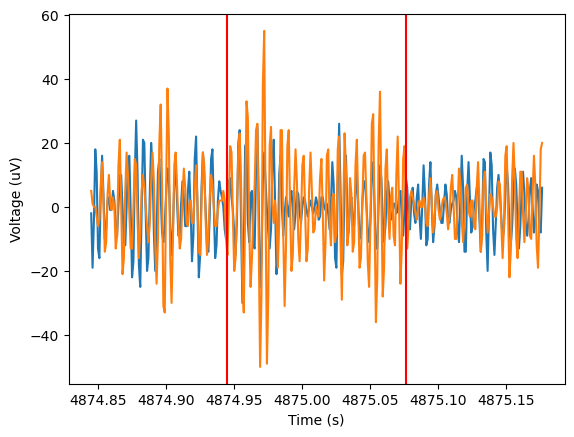

In [51]:
import matplotlib.pyplot as plt

ripple_band_df = (lfp_band.LFPBandV1() & lfp_band_key).fetch1_dataframe()

window = 0.1
i = -1
ripple_start = ripple_times.iloc[i].start_time
ripple_end = ripple_times.iloc[i].end_time
plt.plot(
    ripple_band_df.loc[ripple_start - window : ripple_end + window].index,
    ripple_band_df.loc[ripple_start - window : ripple_end + window].iloc[
        :, ::15
    ],
)
plt.axvline(ripple_start, color="r")
plt.axvline(ripple_end, color="r")

plt.xlabel("Time (s)")
plt.ylabel("Voltage (uV)")